In [2]:
import torch, pandas as pd, numpy as np, time
import matplotlib.pyplot as plt
import random
import torchvision as tv

100.0%


Extracting ./data\EMNIST\raw\gzip.zip to ./data\EMNIST\raw


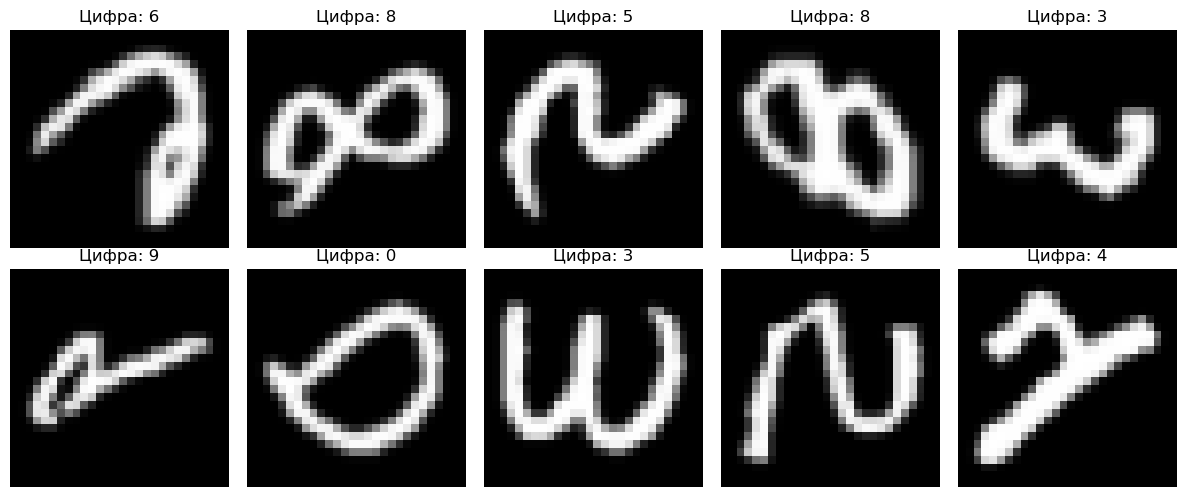

In [3]:
import torchvision.datasets as datasets
# Загрузка EMNIST (цифры) без преобразований
digits_emnist = datasets.EMNIST(
    root='./data',
    split='digits',
    train=True,
    download=True,
    transform=None  # Без преобразований
)

# Названия классов для EMNIST split='digits' (цифры 0–9)
class_names = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

# 10 случайных индексов
random_indices = random.sample(range(len(digits_emnist)), 10)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

# Отображение выбранных изображений
for i, idx in enumerate(random_indices):
    img, label = digits_emnist[idx]
    # Преобразуем PIL изображение в массив numpy
    img_np = np.array(img)

    # Отображение изображения
    axes[i].imshow(img_np, cmap='gray')
    axes[i].set_title(f"Цифра: {class_names[label]}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()


In [4]:
# В случаи если требуется изменить размерность изображений: Подготовка трансформера(в данном случае получение тензора 224*224 и тремя каналами)
transoforms = tv.transforms.Compose([
    tv.transforms.Grayscale(3),
    tv.transforms.Resize((224, 224)),
    tv.transforms.ToTensor()
])

In [12]:
# dataset без трансформации.
train_dataset = tv.datasets.EMNIST('.', train=True, transform=tv.transforms.ToTensor(), download=True, split='digits')
test_dataset = tv.datasets.EMNIST('.', train=False, transform=tv.transforms.ToTensor(), download=True, split='digits')

In [7]:
train_Loader = torch.utils.data.DataLoader(train_dataset, batch_size=256)
test_Loader = torch.utils.data.DataLoader(test_dataset, batch_size=256)

In [36]:
for images, labels in train_Loader:
  print(f"Размер батча: {images.shape}")
  print(f"Размер одного изображения: {images[0].shape}")
  break  # Выходим после первого батча

print(f'Общее количество батчей: {len(train_Loader)}\n'
      f'Общее количество изображений в датасете: {len(train_Loader.dataset)}\n')

Размер батча: torch.Size([256, 1, 28, 28])
Размер одного изображения: torch.Size([1, 28, 28])
Общее количество батчей: 938
Общее количество изображений в датасете: 240000



In [34]:
model_ResNet_18 = tv.models.resnet18(pretrained=False) #  не предобученная модель!

C:\Users\Andrey\anaconda3\envs\gpu_env\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\Andrey\anaconda3\envs\gpu_env\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [39]:
from torchinfo import summary
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
summary(model_ResNet_18, input_size=(1, 3, 224, 224), device=device)

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 1000]                 --
├─Conv2d: 1-1                            [1, 64, 112, 112]         9,408
├─BatchNorm2d: 1-2                       [1, 64, 112, 112]         128
├─ReLU: 1-3                              [1, 64, 112, 112]         --
├─MaxPool2d: 1-4                         [1, 64, 56, 56]           --
├─Sequential: 1-5                        [1, 64, 56, 56]           --
│    └─BasicBlock: 2-1                   [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-1                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-2             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-3                    [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-4                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-5             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-6                    [1, 64, 56, 56]           --
│

In [21]:
model_ResNet_18.conv1 = torch.nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1)  # для 28×28, 1 канал. Было: conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
model_ResNet_18.fc = torch.nn.Linear(512, 10)  # заменяем последний слой на 10 классов

In [22]:
# Фнкция потерь. Она автоматически применяет softmax к выходам модели (не нужно делать это отдельно)
loss = torch.nn.CrossEntropyLoss()

In [24]:
def optimizer(model, lr=0.01):
  return torch.optim.Adam(model.parameters(), lr=lr) # weight_decay=1e-5 - L2 регуляризация

In [25]:
def train_model(model, optimizer_, num_epochs=10):
    train_losses = []
    val_losses = []

    # Определяем устройство
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)  # Перемещаем модель на устройство

    for ep in range(num_epochs):
        # Обучение (train)
        train_iters, train_passed = 0, 0
        train_loss, train_acc = 0., 0.
        start = time.time()

        model.train()
        for X, y in train_Loader: # ДАННЫЕ ДЛЯ ОБУЧЕНИЯ
            X = X.to(device)  # Переносим на устройство
            y = y.to(device)  # Переносим на устройство

            optimizer_.zero_grad()
            y_pred = model(X)
            l = loss(y_pred, y)
            l.backward()
            optimizer_.step()
            train_loss += l.item()
            train_acc += (y_pred.argmax(dim=1) == y).sum().item()
            train_iters += 1
            train_passed += len(X)

        # Валидация (test)
        test_iters, test_passed = 0, 0
        test_loss, test_acc = 0., 0.
        model.eval()
        with torch.no_grad():  # Отключаем вычисление градиентов
            for X, y in test_Loader:      # ТЕСТОВЫЕ ДАННЫЕ
                X = X.to(device)  # Обязательно переносим на устройство!
                y = y.to(device)  # Обязательно переносим на устройство!

                y_pred = model(X)
                l = loss(y_pred, y)
                test_loss += l.item()
                test_acc += (y_pred.argmax(dim=1) == y).sum().item()
                test_iters += 1
                test_passed += len(X)

        # Усредняем потери
        avg_train_loss = train_loss / train_iters
        avg_test_loss = test_loss / test_iters

        train_losses.append(avg_train_loss)
        val_losses.append(avg_test_loss)

        print("ep: {}, taked: {:.3f}, train_loss: {:.4f}, train_acc: {:.4f}, test_loss: {:.4f}, test accuracy: {:.4f}".format(
            ep,
            time.time() - start,
            avg_train_loss,
            train_acc / train_passed,
            avg_test_loss,
            test_acc / test_passed
        ))

    return train_losses, val_losses


In [26]:
trainer_1 = optimizer(model=model_ResNet_18, lr=0.001)

In [28]:
import pickle
import json

# ОБУЧЕНИЕ
train_losses, val_losses = train_model(
    model=model_ResNet_18,
    optimizer_=trainer_1,
    num_epochs=10
)

# 1. Сохранение в pickle
with open('results_model_ResNet_18.pkl', 'wb') as f:
    pickle.dump({
        'train_losses': train_losses,
        'val_losses': val_losses
    }, f)

# 2. Сохранение в JSON
with open('results_model_ResNet_18.json', 'w') as f:
    json.dump({
        'train_losses': train_losses,
        'val_losses': val_losses
    }, f, indent=4)

ep: 0, taked: 109.963, train_loss: 0.0051, train_acc: 0.9985, test_loss: 0.0200, test accuracy: 0.9953
ep: 1, taked: 109.473, train_loss: 0.0044, train_acc: 0.9988, test_loss: 0.0197, test accuracy: 0.9957
ep: 2, taked: 110.103, train_loss: 0.0046, train_acc: 0.9986, test_loss: 0.0186, test accuracy: 0.9965
ep: 3, taked: 109.528, train_loss: 0.0037, train_acc: 0.9989, test_loss: 0.0178, test accuracy: 0.9960
ep: 4, taked: 109.693, train_loss: 0.0032, train_acc: 0.9990, test_loss: 0.0276, test accuracy: 0.9945
ep: 5, taked: 110.259, train_loss: 0.0034, train_acc: 0.9991, test_loss: 0.0241, test accuracy: 0.9954
ep: 6, taked: 109.538, train_loss: 0.0023, train_acc: 0.9994, test_loss: 0.0207, test accuracy: 0.9965
ep: 7, taked: 110.289, train_loss: 0.0032, train_acc: 0.9990, test_loss: 0.0216, test accuracy: 0.9957
ep: 8, taked: 113.065, train_loss: 0.0021, train_acc: 0.9993, test_loss: 0.0247, test accuracy: 0.9956
ep: 9, taked: 111.846, train_loss: 0.0022, train_acc: 0.9993, test_loss: 

In [29]:
import json

with open('results_model_ResNet_18.json', 'r') as f:
    results = json.load(f)

# Преобразуем в DataFrame для удобного просмотра
df_model_ResNet_18 = pd.DataFrame({
    'Epoch': range(len(results['train_losses'])),
    'Train Loss': results['train_losses'],
    'Validation Loss': results['val_losses']
})

df_model_ResNet_18

,Epoch,Train Loss,Validation Loss
0,0,0.005126,0.019995
1,1,0.004442,0.019654
2,2,0.004650,0.018587
3,3,0.003724,0.017766
4,4,0.003203,0.027586
5,5,0.003366,0.024103
6,6,0.002256,0.020666
7,7,0.003198,0.021571
8,8,0.002099,0.024656
9,9,0.002197,0.020810


In [30]:
def chart_plot(df):
  plt.figure(figsize=(10, 6))
  plt.plot(df['Epoch'], df['Train Loss'], label='Train Loss', marker='o')
  plt.plot(df['Epoch'], df['Validation Loss'], label='Validation Loss', marker='s')
  plt.title('Training and Validation Loss')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.legend()
  plt.grid(True, alpha=0.3)
  plt.show()

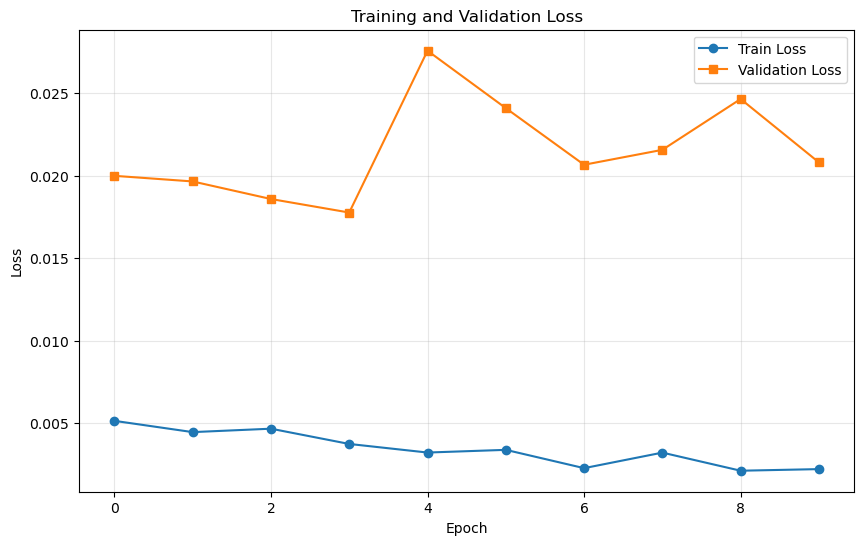

In [31]:
chart_plot(df_model_ResNet_18)